# Tema : Modelos ARCH/GARCH
![](src/img/logo_utb.png){width=40%} 
![](src/img/logo_etd.png){width=40%}
- **Profesor:**
- **Fernando Salcedo Mejía, Eco Msc.**
- Programa de Ciencias de Datos | Escuela de transformación digital.
- 2026-1

In [108]:
# Librerias necesarias

# Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Modelos de tiempo
from arch import arch_model

from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import jarque_bera

import warnings
warnings.filterwarnings('ignore')


### Ejercicio 1. Modelación de los precios de Google.

Usando los datos de precios de cierre de Google en la bolsa de valores, estimar un modelo ARCH/GARCH


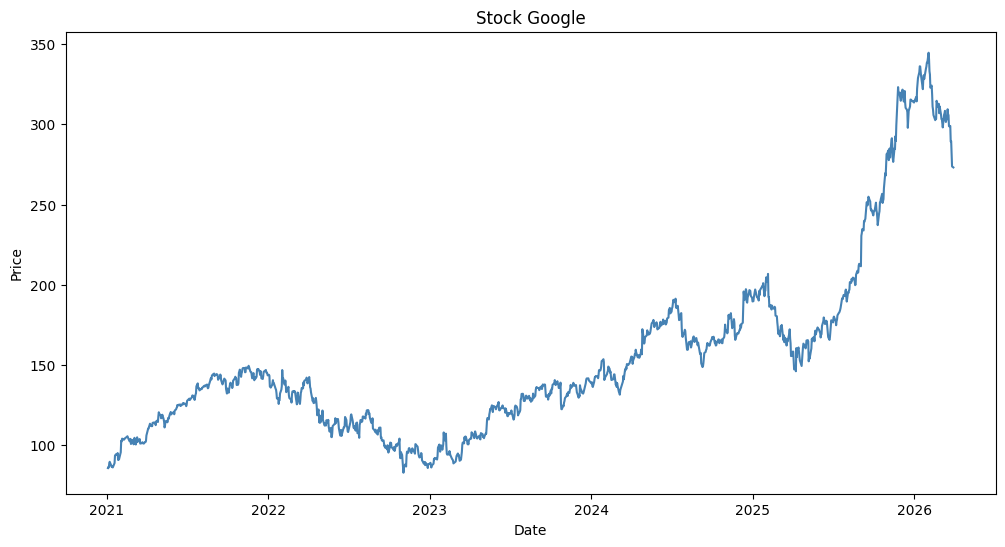

In [109]:
# Descargar datos de la serie de tiempo
df = yf.download('GOOG', start='2021-01-01', end='2026-03-31', progress=False)
df = df['Close']
df.index = pd.to_datetime(df.index)
price_google = df.GOOG

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(price_google.index, price_google, color='steelblue')
ax.set_title('Stock Google')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
plt.show()

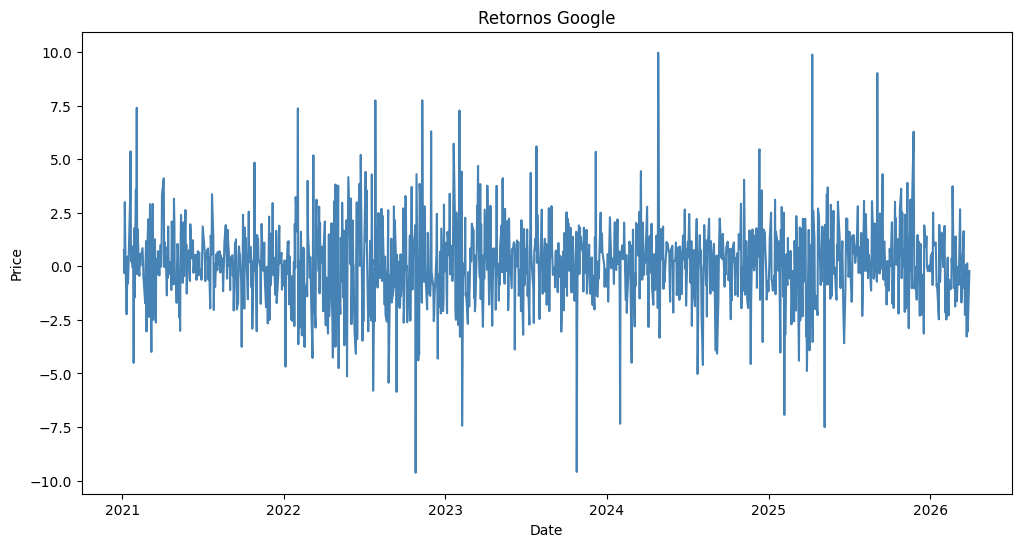

In [110]:
# retornos
retornos = 100 * price_google.pct_change().dropna()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(retornos.index, retornos, color='steelblue')
ax.set_title('Retornos Google')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
plt.show()

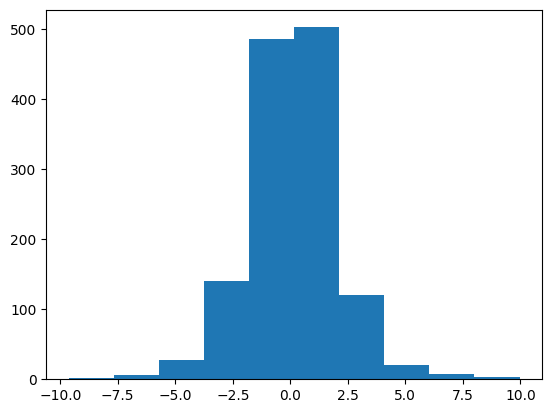

In [111]:
# Distribución de los retornos. Suelen tener colas largas.
fig = plt.hist(retornos)

In [112]:
# Test de normalidad Jarque-Bera
def test_normalidad(datos, titulo = "Prueba de normalidad"):
    jb_stat, p_value = jarque_bera(retornos)

    print("=" * 80)
    print(titulo)
    print("=" * 80)

    print(f"Estadístico Jarque-Bera: {jb_stat}")
    print(f"p-valor: {p_value}")

    # Interpretación
    if p_value < 0.05:
        print("Resultado: Se rechaza la normalidad (p < 0.05).")
        print("Los datos tienen exceso de curtosis o asimetría.")
    else:
        print("Resultado: No se rechaza la normalidad. Los datos son aproximadamente normales.")
    print("=" * 80)
test_normalidad(retornos)

Prueba de normalidad
Estadístico Jarque-Bera: 589.1643825070615
p-valor: 1.160325593408888e-128
Resultado: Se rechaza la normalidad (p < 0.05).
Los datos tienen exceso de curtosis o asimetría.


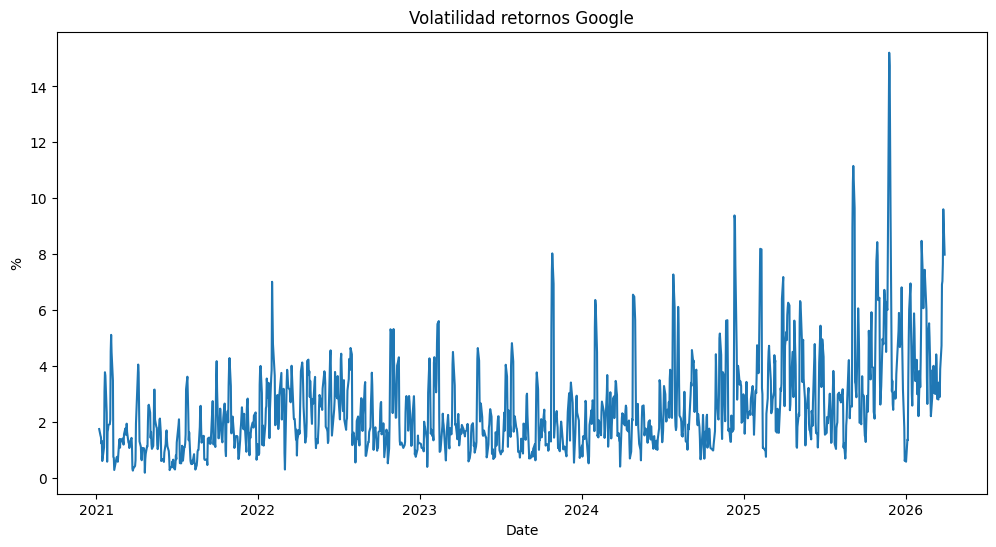

In [113]:
# Estimar de volatilidad Inspección visual de std móvil
# ventana semanal
ventana = 5
varianza_movil = price_google.rolling(ventana).std()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(varianza_movil.index, varianza_movil)
ax.set_title('Volatilidad retornos Google')
ax.set_xlabel('Date')
ax.set_ylabel('%')
plt.show()

In [114]:
# Prueba de Dickey-Fuller Aumentada (ADF): Verifica que tus retornos sean estacionarios
def test_estacionariedad(datos):
    # Augmented Dickey-Fuller
    adf_result = adfuller(datos)
    # KPSS
    kpss_result = kpss(datos, regression='c')

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Prueba Augmented Dickey-Fuller (ADF)", "Prueba KPSS"],
        'Estadístico' : [round(adf_result[0],  4), round(kpss_result[0],  4)],
        'P-valor'     : [round(adf_result[1], 4), round(kpss_result[1], 4)],
        "Estacionario" : ["Sí" if adf_result[1] < 0.05 else "No", "No" if kpss_result[1] < 0.05 else "Sí"]
    })

    print("=" * 80)
    print("PRUEBA DE ESTACIONARIEDAD")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)


test_estacionariedad(retornos)

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)     -36.3215      0.0           Sí
1                           Prueba KPSS       0.1088      0.1           Sí


In [115]:
# Prueba de Multiplicador de Lagrange (LM) de Engle

# Pasos :
# Ajusta un modelo de media (por ejemplo, ARIMA o regresión) a tu serie temporal y extrae los residuos.
# Elige el número de retardos para la regresión auxiliar normalmente 5 (una semana) o 10 (dos semanas).

# Notas interpretacion :
# Valor p > 0,05: No se rechaza H0. No hay evidencia sólida de efectos ARCH; un modelo de varianza constante podría ser adecuado.
# Valor p ≤ 0,05: Se rechaza H0. Hay efectos ARCH presentes. Considere ajustar un modelo GARCH o EGARCH para modelar explícitamente la varianza variable en el tiempo.
# Elección de retardos: Por defecto, se suelen usar 5 retardos para datos diarios o 10 retardos para datos de mayor frecuencia. Si los resultados son marginales, intente variar el número de retardos para comprobar la robustez.
# Tamaño del efecto: Un estadístico LM grande (en relación con los valores críticos de chi-cuadrado) indica una agrupación de volatilidad más pronunciada, lo que podría requerir modelos de volatilidad más sofisticados.
# Por ejemplo, si prueba los residuos AR(1) con 5 retardos y obtiene LM = 10,00, gl = 5, p = 0,075, no rechazaría H0. Pero si la misma serie analizada con 10 retardos arroja un valor de p = 0,012, los efectos ARCH son evidentes y se debería considerar un modelo GARCH.

model_fit = ARIMA(retornos, order=(1, 0, 0)).fit()
residuos = model_fit.resid
# Aplicar test Engle ARCH sobre residuos (lag = 5 o lag = 10 usualmente)
arch_test = het_arch(residuos, nlags=5)

# Reporte
labels = ['Estadístico LM', 'p-value LM', 'Estadístico F', 'p-value F']
df_test_arch = pd.DataFrame([arch_test], columns=labels)

# Lógica de decisión
p_val = arch_test[1]
if p_val < 0.05:
    df_test_arch["Conclusión"] = "Hay presencia de efectos ARCH."
else:
    df_test_arch["Conclusión"] = "No hay evidencia de heterocedasticidad condicional."

print("=" * 100)
print("Resultados de la Prueba de Efectos ARCH")
print("=" * 100)
print(df_test_arch.to_string(index=False))
print("=" * 100)


Resultados de la Prueba de Efectos ARCH
 Estadístico LM  p-value LM  Estadístico F  p-value F                     Conclusión
      13.601545    0.018349       2.736272    0.01817 Hay presencia de efectos ARCH.


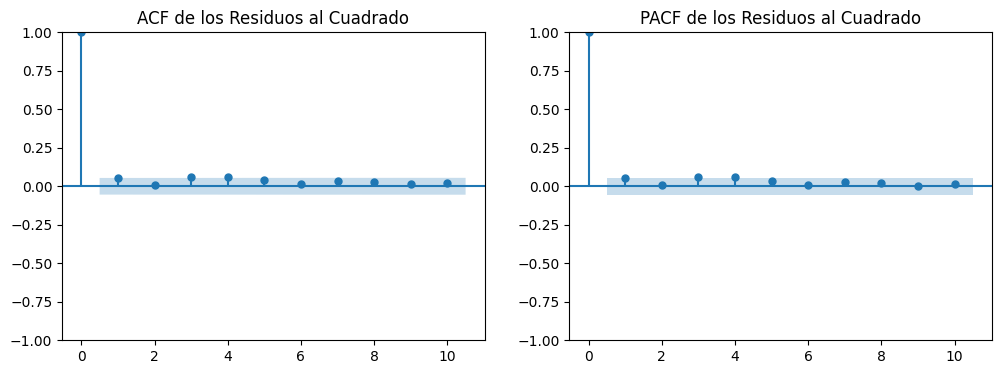

Ljung-Box test autocorrelacion
      lb_stat  lb_pvalue
1    3.548234   0.059609
2    3.715061   0.156058
3    8.150078   0.043010
4   13.425665   0.009373
5   15.433880   0.008661
6   15.727428   0.015294
7   17.352854   0.015257
8   18.424378   0.018260
9   18.621344   0.028612
10  19.357002   0.035956


In [116]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Visualizar ACF de residuos al cuadrado
plot_acf(residuos**2, ax=ax[0], lags=10)
ax[0].set_title('ACF de los Residuos al Cuadrado')

# Visualizar PACF de residuos al cuadrado
plot_pacf(residuos**2, ax=ax[1],  lags=10)
ax[1].set_title('PACF de los Residuos al Cuadrado')

plt.show()

# Ljung-Box test autocorrelacion
lb_test = acorr_ljungbox(residuos**2, lags=10, return_df=True)
print("=" * 80)
print("Ljung-Box test autocorrelacion")
print("=" * 80)
print(lb_test.to_string())
print("=" * 80)

## Modelo ARCH/GARCH

Para modelizar la serie, la elección del orden (p, q) de los parámetros se puede hacer por prueba error, analizando cuales de los mismos son estadísticamente significativos. Sin embargo, una opción estandar suele ser el modelo GARCH(1,1).

In [117]:
# Train y test
split_date = pd.to_datetime("2026-03-01")
train = retornos[ :split_date]
test = retornos[split_date: ]

# Modelación GARCH(1, 1)
modelo_garch_11 = arch_model(train, mean='Constant', vol = "GARCH", p=1, q=1, dist="normal").fit()
print(modelo_garch_11.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1815519.041692176
Iteration:      2,   Func. Count:     14,   Neg. LLF: 6387.679723783716
Iteration:      3,   Func. Count:     22,   Neg. LLF: 498428447.82424027
Iteration:      4,   Func. Count:     29,   Neg. LLF: 2688.159331717984
Iteration:      5,   Func. Count:     35,   Neg. LLF: 2675.992048411975
Iteration:      6,   Func. Count:     41,   Neg. LLF: 2690.9935988514717
Iteration:      7,   Func. Count:     47,   Neg. LLF: 2667.499696618307
Iteration:      8,   Func. Count:     53,   Neg. LLF: 2667.3900961049853
Iteration:      9,   Func. Count:     58,   Neg. LLF: 2667.389543272409
Iteration:     10,   Func. Count:     63,   Neg. LLF: 2667.389540473315
Iteration:     11,   Func. Count:     67,   Neg. LLF: 2667.3895404789628
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2667.389540473315
            Iterations: 11
            Function evaluations: 67
            Gradient evaluations

## Interpretación

### Mean Model (El nivel de los retornos)
- mu (0.1532): Es el retorno promedio constante de la serie.
### Volatility Model (Modelo GARCH)
- omega (0.0495): Es la constante de la varianza. En este caso, el p-valor (0.108) es mayor a 0.05, lo que sugiere que la constante no es estadísticamente significativa.
- alpha[1] (0.0200): Representa el efecto de los choques de corto plazo (el residuo al cuadrado del periodo anterior). Como el p-valor (0.0119) es menor a 0.05, es significativo. Los eventos de ayer afectan la volatilidad de hoy.
- beta[1] (0.9666): Representa la persistencia de la volatilidad (la varianza de ayer). Su p-valor (0.000) es extremadamente pequeño, indicando una relevancia total.
### Persistencia: 
- Como la suma es muy cercana a 1, la volatilidad es altamente persistente. Si hay un pico de incertidumbre en Google, tardará mucho tiempo en regresar a su promedio histórico (decae lentamente).
### Estacionariedad: 
- Como la suma es menor a 1, el proceso es estacionario en varianza. El modelo es estable y no "explota" hacia el infinito.

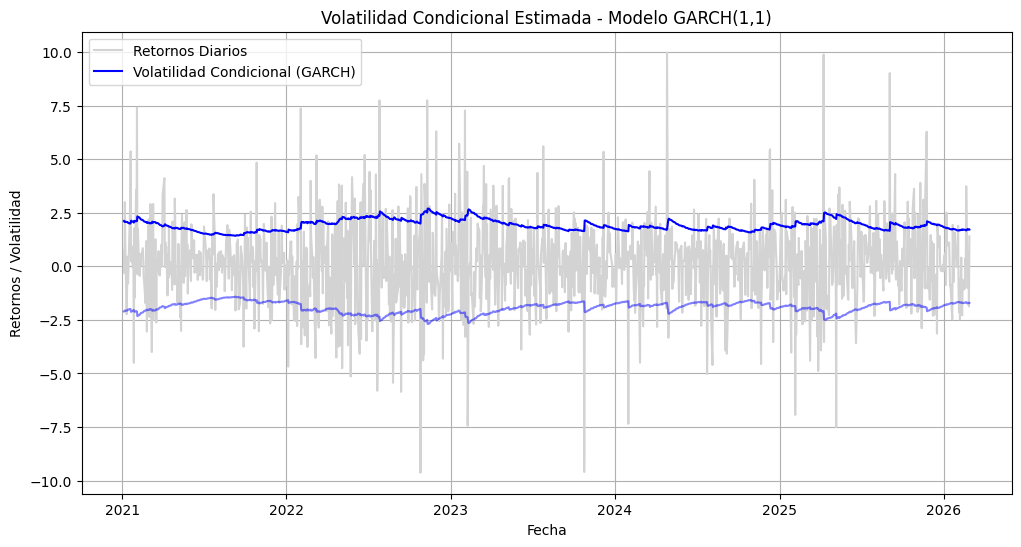

In [118]:
# Extraer la volatilidad condicional estimada (es la desviación estándar sigma_t)
volatilidad_estimada = modelo_garch_11.conditional_volatility

plt.figure(figsize=(12, 6))
# Graficamos los retornos en gris para que sirvan de fondo
plt.plot(train, color='lightgray', label='Retornos Diarios')

# Graficamos la volatilidad condicional
plt.plot(volatilidad_estimada, color='blue', label='Volatilidad Condicional (GARCH)')
plt.plot(-volatilidad_estimada, color='blue', alpha=0.5)

plt.title('Volatilidad Condicional Estimada - Modelo GARCH(1,1)')
plt.ylabel('Retornos / Volatilidad')
plt.xlabel('Fecha')
plt.legend()
plt.grid()
plt.show()

In [119]:
## Test de normalidad de los residuos del modelo GARCH
# Obtener residuos estandarizados del modelo ajustado
std_resid = modelo_garch_11.resid / modelo_garch_11.conditional_volatility
std_resid = std_resid.dropna()

test_normalidad(std_resid, "Prueba de normalidad residuos GARCH(1, 1)")


Prueba de normalidad residuos GARCH(1, 1)
Estadístico Jarque-Bera: 589.1643825070615
p-valor: 1.160325593408888e-128
Resultado: Se rechaza la normalidad (p < 0.05).
Los datos tienen exceso de curtosis o asimetría.


In [120]:
## Restimación del modelo con distribución t-student
# Modelación GARCH(1, 1) t-studen
modelo_garch_11_t = arch_model(train, mean='Constant', vol = "GARCH", p=1, q=1, dist="t").fit()
print(modelo_garch_11_t.summary())


Iteration:      1,   Func. Count:      7,   Neg. LLF: 29717.942555932877
Iteration:      2,   Func. Count:     16,   Neg. LLF: 4327.001665905427
Iteration:      3,   Func. Count:     25,   Neg. LLF: 10682.821037480167
Iteration:      4,   Func. Count:     35,   Neg. LLF: 3710.4405583098414
Iteration:      5,   Func. Count:     42,   Neg. LLF: 3725.821146825613
Iteration:      6,   Func. Count:     50,   Neg. LLF: 2599.6120633075416
Iteration:      7,   Func. Count:     57,   Neg. LLF: 2595.393658733832
Iteration:      8,   Func. Count:     64,   Neg. LLF: 2594.7255166686177
Iteration:      9,   Func. Count:     71,   Neg. LLF: 2592.8274624818896
Iteration:     10,   Func. Count:     77,   Neg. LLF: 2592.796195860808
Iteration:     11,   Func. Count:     83,   Neg. LLF: 2592.799205499393
Iteration:     12,   Func. Count:     90,   Neg. LLF: 2592.779187825698
Iteration:     13,   Func. Count:     96,   Neg. LLF: 2592.777058877825
Iteration:     14,   Func. Count:    102,   Neg. LLF: 2592

In [121]:
# AIC modelos GARCH(1, 1)
print(f"AIC GARC(1, 1) Normal : {modelo_garch_11.aic}")
print(f"AIC GARC(1, 1) T-studend (mejor modelo) : {modelo_garch_11_t.aic}")

AIC GARC(1, 1) Normal : 5342.77908094663
AIC GARC(1, 1) T-studend (mejor modelo) : 5195.5540898189065


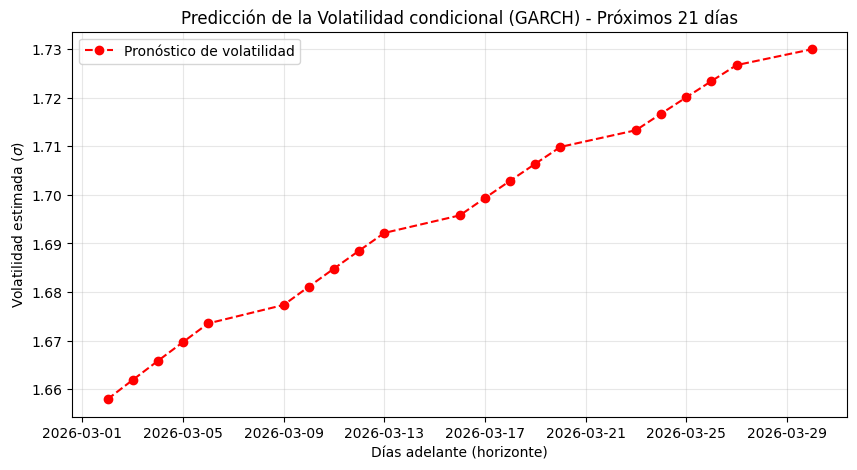

In [143]:
# Pronostico del modelo a 30 dias
horizonte_t = len(test)
forecasts = modelo_garch_11_t.forecast(horizon=horizonte_t, reindex=False)

# Volatilidad
forecast_vol = np.sqrt(forecasts.variance.values[-1, :])

# Graficar volatilidad esperada
plt.figure(figsize=(10, 5))
plt.plot(test.index, forecast_vol, marker='o', linestyle='--', color='red', label='Pronóstico de volatilidad')
plt.title(f'Predicción de la Volatilidad condicional (GARCH) - Próximos {horizonte_t} días')
plt.xlabel('Días adelante (horizonte)')
plt.ylabel('Volatilidad estimada ($\sigma$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

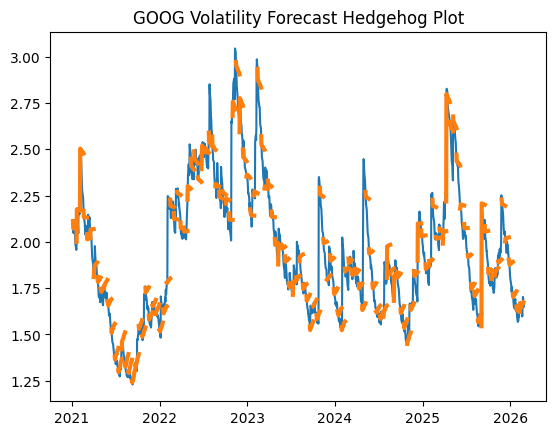

In [137]:
fig = modelo_garch_11_t.hedgehog_plot(plot_type="volatility")
plt.show()